## soma branches

In [2]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm

files = list(Path("sk_lod1_783_healed_260609").glob("*.swc"))
rows = []

for f in tqdm(files):
    try:
        d = pd.read_csv(
            f, sep=r"\s+", comment="#", header=None,
            usecols=[0, 1, 6], names=["id", "type", "parent"],
            dtype={"id": "int64", "type": "int16", "parent": "int64"}
        )
        soma = set(d.loc[d["type"].eq(1), "id"])
        rows.append((f.stem, len(soma), d["parent"].isin(soma).sum()))
    except Exception as e:
        print(f"Error: {f.name}: {e}")

df_check = pd.DataFrame(rows, columns=["neuron", "n_soma", "soma_children"])

print("\n===== Soma children distribution =====")
print(df_check["soma_children"].value_counts().sort_index())

print("\n===== Summary =====")
print(df_check["soma_children"].describe())

print("\n===== Abnormal (>1) =====")
print(f"{df_check['soma_children'].gt(1).sum()} / {len(df_check)}")

print("\n===== Multiple soma nodes =====")
print(f"{df_check['n_soma'].gt(1).sum()} / {len(df_check)}")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 139273/139273 [36:03<00:00, 64.36it/s]



===== Soma children distribution =====
soma_children
0       4584
1      90131
2      29841
3      11675
4       1962
       ...  
260        1
346        1
638        1
957        1
973        1
Name: count, Length: 87, dtype: int64

===== Summary =====
count    139273.000000
mean          1.509582
std           4.786127
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         973.000000
Name: soma_children, dtype: float64

===== Abnormal (>1) =====
44558 / 139273

===== Multiple soma nodes =====
0 / 139273


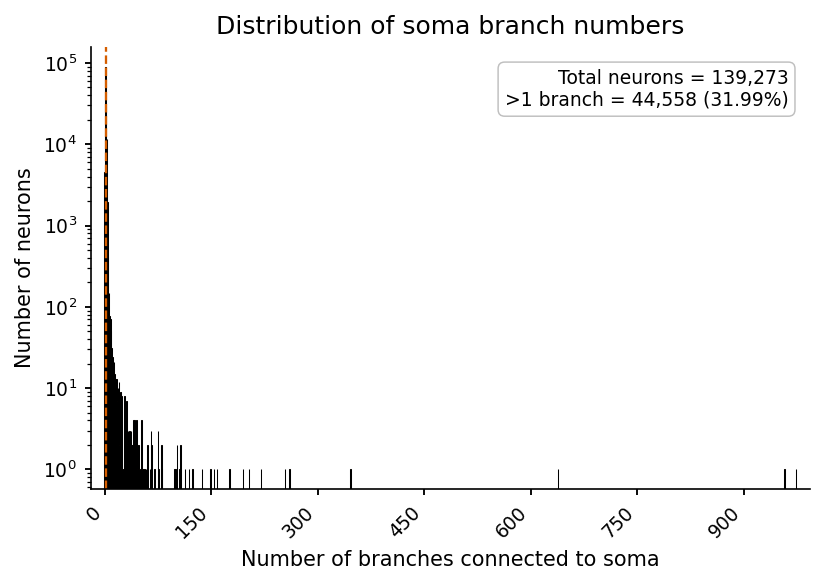

In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

out = Path("pic")
out.mkdir(parents=True, exist_ok=True)

x = df_check["soma_children"].dropna().astype(int)
c = x.value_counts().sort_index()
n, n_gt1 = len(x), x.gt(1).sum()

plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})
fig, ax = plt.subplots(figsize=(5.6, 4.0), dpi=150)

ax.bar(
    c.index,
    c.values,
    width=0.8,
    color=np.where(c.index > 1, "#D55E00", "#4D4D4D"),
    edgecolor="black",
    linewidth=0.5
)

ax.axvline(1.5, color="#D55E00", ls="--", lw=1.1)

ax.text(
    0.97,
    0.95,
    f"Total neurons = {n:,}\n"
    f">1 branch = {n_gt1:,} ({n_gt1 / n * 100:.2f}%)",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=.35",
        fc="white",
        ec=".75",
        lw=.7
    )
)

ax.set(
    xlabel="Number of branches connected to soma",
    ylabel="Number of neurons",
    title="Distribution of soma branch numbers",
    yscale="log"
)

ax.xaxis.set_major_locator(MaxNLocator(nbins=10, integer=True))
ax.tick_params(axis="x", labelrotation=45)
plt.setp(ax.get_xticklabels(), ha="right")

ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="both", labelsize=9, width=.9, length=3)
ax.margins(x=0.02)

fig.tight_layout()

for ext, dpi in [("pdf", None), ("png", 600)]:
    fig.savefig(
        out / f"soma_branch_number_count.{ext}",
        dpi=dpi,
        bbox_inches="tight"
    )

plt.show()

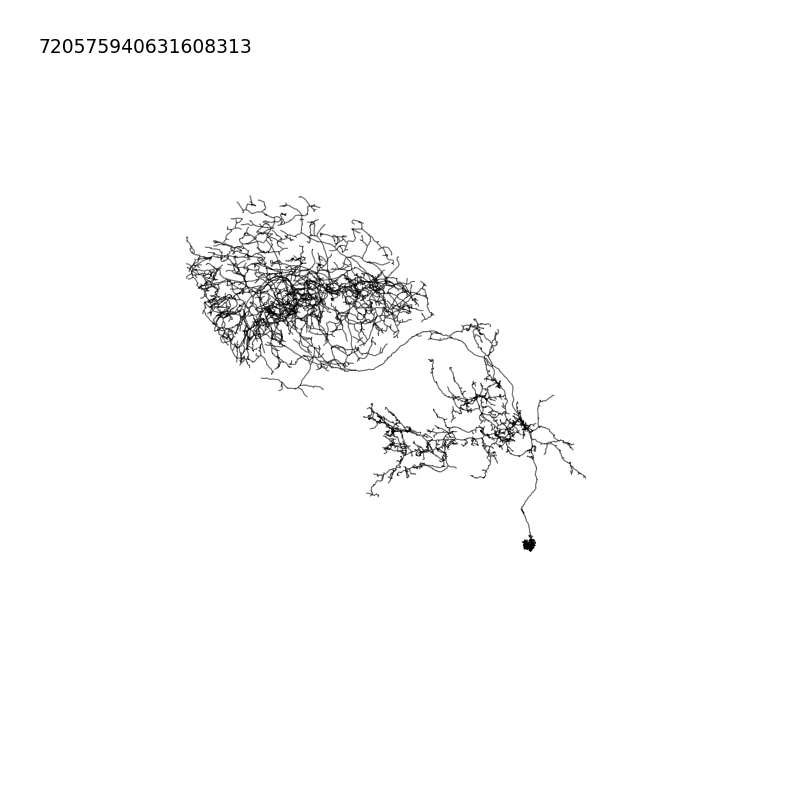

In [94]:
from pathlib import Path
from itertools import product, combinations
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

nid = "720575940631608313"
swc_dir = Path("sk_lod1_783_healed_260609")
out = Path("pic")
out.mkdir(parents=True, exist_ok=True)

elev, azim = 22, -58
show_axes = False

d = np.atleast_2d(np.loadtxt(
    swc_dir / f"{nid}.swc",
    comments="#",
    usecols=(0, 1, 2, 3, 4, 6)
))

ids = d[:, 0].astype(np.int64)
xyz = d[:, 2:5] / 1000
parents = d[:, 5].astype(np.int64)
idx = {v: i for i, v in enumerate(ids)}

segments = np.array([
    [xyz[idx[p]], xyz[i]]
    for i, p in enumerate(parents)
    if p in idx
])

fig = plt.figure(figsize=(6.4, 5.5), dpi=150)
ax = fig.add_subplot(
    111,
    projection="3d",
    computed_zorder=False
)

if len(segments):
    ax.add_collection3d(Line3DCollection(
        segments,
        colors="black",
        linewidths=.5,
        alpha=.72,
        zorder=2
    ))

ax.text2D(
    .03,
    .97,
    nid,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9
)

center = (xyz.min(0) + xyz.max(0)) / 2
radius = max(
    np.ptp(xyz, axis=0).max() / 2,
    1e-6
)

for setter, c in zip(
    [ax.set_xlim, ax.set_ylim, ax.set_zlim],
    center
):
    setter(c - radius, c + radius)

ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=elev, azim=azim)

if show_axes:
    ax.set_xlabel("X (μm)", fontsize=8, labelpad=1)
    ax.set_ylabel("Y (μm)", fontsize=8, labelpad=1)
    ax.set_zlabel("Z (μm)", fontsize=8, labelpad=1)

    ax.tick_params(
        labelsize=8,
        width=.8,
        length=3,
        pad=1
    )

    ax.grid(True)

    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((0.94, 0.97, 0.99, 0.28))
        axis.pane.set_edgecolor((0.72, 0.78, 0.84, 0.45))
        axis.line.set_color((1, 1, 1, 0))
        axis._axinfo["grid"].update({
            "color": (0.58, 0.68, 0.78, 0.42),
            "linewidth": .5,
            "linestyle": "-"
        })

    lims = [
        ax.get_xlim(),
        ax.get_ylim(),
        ax.get_zlim()
    ]

    corners = np.array(list(product(*lims)))
    box_center = np.array([
        np.mean(v)
        for v in lims
    ])

    er, ar = np.deg2rad([elev, azim])

    camera = np.array([
        np.cos(er) * np.cos(ar),
        np.cos(er) * np.sin(ar),
        np.sin(er)
    ])

    top = corners[
        np.isclose(
            corners[:, 2],
            lims[2][1]
        )
    ]

    hidden = top[
        np.argmax(
            (top - box_center) @ camera
        )
    ]

    for p, q in combinations(corners, 2):
        if (
            np.sum(~np.isclose(p, q)) == 1
            and not np.allclose(p, hidden)
            and not np.allclose(q, hidden)
        ):
            ax.plot(
                *zip(p, q),
                color="#AEBBC8",
                lw=.8,
                zorder=0
            )
else:
    ax.set_axis_off()

fig.tight_layout()

suffix = "axes" if show_axes else "no_axes"

for ext, dpi in [
    ("pdf", None),
    ("png", 600)
]:
    fig.savefig(
        out / f"{nid}_neuron_3d_{suffix}.{ext}",
        dpi=dpi,
        bbox_inches="tight"
    )

plt.show()

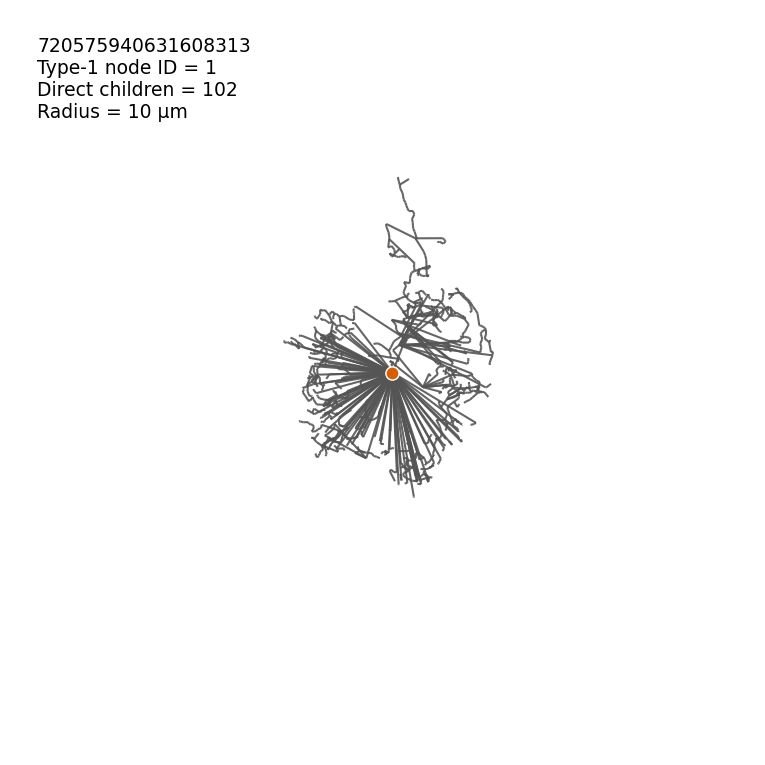

In [97]:
from pathlib import Path
from itertools import product, combinations
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection


nid = "720575940631608313"
swc_dir = Path("sk_lod1_783_healed_260609")
out = Path("pic")
out.mkdir(parents=True, exist_ok=True)

zoom_radius = 10

elev, azim = 22, -58
show_axes = False
show_target_id = False


d = np.atleast_2d(np.loadtxt(
    swc_dir / f"{nid}.swc",
    comments="#",
    usecols=(0, 1, 2, 3, 4, 6)
))

ids = d[:, 0].astype(np.int64)
types = d[:, 1].astype(np.int16)
xyz = d[:, 2:5] / 1000
parents = d[:, 5].astype(np.int64)

idx = {node_id: i for i, node_id in enumerate(ids)}

type1_idx = np.flatnonzero(types == 1)

if len(type1_idx) == 0:
    raise ValueError("No type=1 node found")

if len(type1_idx) > 1:
    print("Multiple type=1 nodes found, using the first one")

target_i = type1_idx[0]
target_node_id = ids[target_i]
target_xyz = xyz[target_i]
target_type = types[target_i]

segment_indices = [
    i for i, parent in enumerate(parents)
    if parent in idx
]

segments = np.array([
    [xyz[idx[parents[i]]], xyz[i]]
    for i in segment_indices
])

lower = target_xyz - zoom_radius
upper = target_xyz + zoom_radius

segment_min = segments.min(axis=1)
segment_max = segments.max(axis=1)

local_segment_mask = np.all(
    (segment_max >= lower) & (segment_min <= upper),
    axis=1
)

local_segments = segments[local_segment_mask]

local_node_mask = np.all(
    (xyz >= lower) & (xyz <= upper),
    axis=1
)

fig = plt.figure(figsize=(5.6, 5.2), dpi=150)

ax = fig.add_subplot(
    111,
    projection="3d",
    computed_zorder=False
)

if len(local_segments):
    ax.add_collection3d(Line3DCollection(
        local_segments,
        colors="#555555",
        linewidths=1,
        alpha=.9,
        zorder=2
    ))

ax.scatter(
    *target_xyz,
    s=40,
    color="#D55E00",
    edgecolor="white",
    linewidth=.7,
    depthshade=False,
    zorder=10
)

if show_target_id:
    offset = zoom_radius * .035
    ax.text(
        target_xyz[0] + offset,
        target_xyz[1] + offset,
        target_xyz[2] + offset,
        str(target_node_id),
        color="#D55E00",
        fontsize=8,
        ha="left",
        va="bottom",
        zorder=11
    )

child_counts = dict(zip(*np.unique(parents[parents != -1], return_counts=True)))
n_children = child_counts.get(target_node_id, 0)

ax.text2D(
    .03,
    .97,
    (
        f"{nid}\n"
        f"Type-1 node ID = {target_node_id}\n"
        f"Direct children = {n_children}\n"
        f"Radius = {zoom_radius} μm"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9
)

ax.set_xlim(lower[0], upper[0])
ax.set_ylim(lower[1], upper[1])
ax.set_zlim(lower[2], upper[2])

ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=elev, azim=azim)

if show_axes:
    ax.set_xlabel("X (μm)", fontsize=8, labelpad=1)
    ax.set_ylabel("Y (μm)", fontsize=8, labelpad=1)
    ax.set_zlabel("Z (μm)", fontsize=8, labelpad=1)

    ax.tick_params(
        labelsize=8,
        width=.8,
        length=3,
        pad=1
    )

    ax.grid(True)

    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((0.94, 0.97, 0.99, 0.25))
        axis.pane.set_edgecolor((0.72, 0.78, 0.84, 0.4))
        axis.line.set_color((1, 1, 1, 0))
        axis._axinfo["grid"].update({
            "color": (0.58, 0.68, 0.78, 0.38),
            "linewidth": .45,
            "linestyle": "-"
        })

    lims = [
        ax.get_xlim(),
        ax.get_ylim(),
        ax.get_zlim()
    ]

    corners = np.array(list(product(*lims)))
    box_center = np.array([np.mean(v) for v in lims])

    er, ar = np.deg2rad([elev, azim])

    camera = np.array([
        np.cos(er) * np.cos(ar),
        np.cos(er) * np.sin(ar),
        np.sin(er)
    ])

    top = corners[
        np.isclose(corners[:, 2], lims[2][1])
    ]

    hidden = top[
        np.argmax((top - box_center) @ camera)
    ]

    for p, q in combinations(corners, 2):
        if (
            np.sum(~np.isclose(p, q)) == 1
            and not np.allclose(p, hidden)
            and not np.allclose(q, hidden)
        ):
            ax.plot(
                *zip(p, q),
                color="#AEBBC8",
                lw=.8,
                zorder=0
            )
else:
    ax.set_axis_off()

fig.tight_layout()

suffix = "axes" if show_axes else "no_axes"

for ext, dpi in [("pdf", None), ("png", 600)]:
    fig.savefig(
        out / (
            f"{nid}_type1_node_{target_node_id}_"
            f"radius_{zoom_radius}_{suffix}.{ext}"
        ),
        dpi=dpi,
        bbox_inches="tight"
    )

plt.show()

## type5 branch

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm

swc_dir = Path("sk_lod1_783_healed_260609")

def count_type5(path):
    try:
        d = np.loadtxt(path, comments="#", usecols=(0, 1, 6), ndmin=2)
        ids, types, parents = d[:, 0].astype(np.int64), d[:, 1].astype(np.int16), d[:, 2].astype(np.int64)

        if np.unique(ids).size != ids.size:
            raise ValueError("Duplicate node IDs")

        p, n = np.unique(parents[parents != -1], return_counts=True)
        counts = np.zeros(ids.size, dtype=np.int32)

        if p.size:
            pos = np.searchsorted(p, ids)
            valid = pos < p.size
            match = np.zeros(ids.size, bool)
            match[valid] = p[pos[valid]] == ids[valid]
            counts[match] = n[pos[match]]

        b = counts[types == 5]

        return {
            "file": path.name,
            "relative_path": str(path.relative_to(swc_dir)),
            "type5_n": len(b),
            "branch_gt2": int((b > 2).sum()),
            "branch_eq2": int((b == 2).sum()),
            "no_branch": int((b == 1).sum()),
            "terminal_n": int((b == 0).sum()),
            "has_terminal": bool((b == 0).any()),
            "error": None
        }

    except Exception as e:
        return {
            "file": path.name,
            "relative_path": str(path.relative_to(swc_dir)),
            "type5_n": np.nan,
            "branch_gt2": np.nan,
            "branch_eq2": np.nan,
            "no_branch": np.nan,
            "terminal_n": np.nan,
            "has_terminal": np.nan,
            "error": str(e)
        }

files = sorted(swc_dir.rglob("*.swc"))
df_type5 = pd.DataFrame(
    count_type5(p) for p in tqdm(files, desc="Counting Type-5 branches")
)
df_type5.to_csv("type5_branch_counts.csv", index=False)

ok = df_type5[df_type5["error"].isna()]

print("SWC files:", len(df_type5))
print("Errors:", df_type5["error"].notna().sum())
print("Total Type-5 nodes:", int(ok["type5_n"].sum()))
print("Type-5 nodes with >2 children:", int(ok["branch_gt2"].sum()))
print("Type-5 nodes with exactly 2 children:", int(ok["branch_eq2"].sum()))
print("Type-5 nodes with exactly 1 child:", int(ok["no_branch"].sum()))
print("Terminal Type-5 nodes:", int(ok["terminal_n"].sum()))
print("Files containing terminal Type-5 nodes:", int(ok["has_terminal"].sum()))

Counting Type-5 branches: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 139273/139273 [04:30<00:00, 515.53it/s]


SWC files: 139273
Errors: 0
Total Type-5 nodes: 36931591
Type-5 nodes with >2 children: 2508792
Type-5 nodes with exactly 2 children: 34422799
Type-5 nodes with exactly 1 child: 0
Terminal Type-5 nodes: 0
Files containing terminal Type-5 nodes: 0


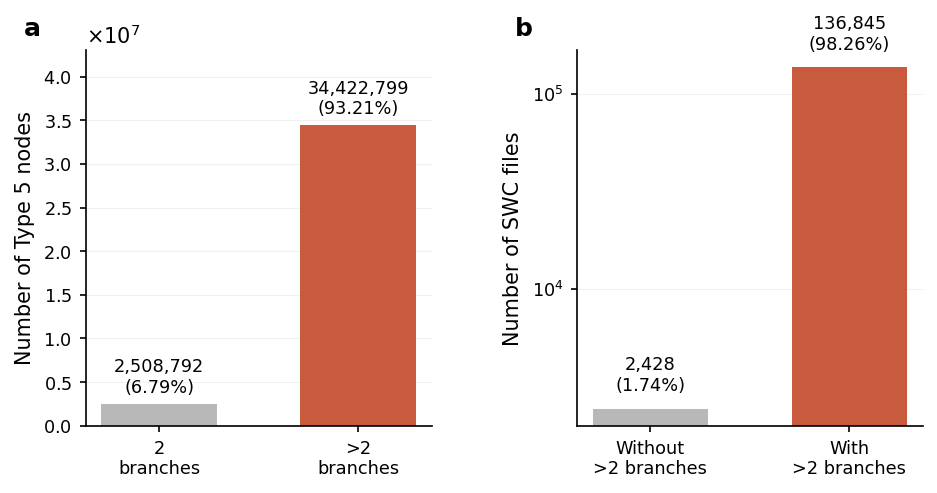

In [8]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, LogFormatterSciNotation, NullLocator

out = Path("pic")
out.mkdir(parents=True, exist_ok=True)

ok = df_type5[df_type5["error"].isna()]
nt = int(ok["type5_n"].sum())
ng = int(ok["branch_eq2"].sum())
nf = len(ok)
fg = int(ok["branch_gt2"].gt(0).sum())

data = [
    (["2\nbranches", ">2\nbranches"], [nt - ng, ng],
     "Number of Type 5 nodes"),
    (["Without\n>2 branches", "With\n>2 branches"], [nf - fg, fg],
     "Number of SWC files")
]

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.25), dpi=150)
fig.subplots_adjust(wspace=.42)

for label, ax, (x, y, ylabel) in zip("ab", axes, data):
    bars = ax.bar(
        x, y, width=.58,
        color=["#B8B8B8", "#C85A3D"],
        edgecolor="none"
    )

    positive = [v for v in y if v > 0]
    log = len(positive) == 2 and max(positive) / min(positive) >= 20

    if log:
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10))
        ax.yaxis.set_minor_locator(NullLocator())
    else:
        ax.set_ylim(0, max(y) * 1.25 if max(y) else 1)
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))
        ax.yaxis.set_major_formatter(formatter)

    total = sum(y)

    for bar, value in zip(bars, y):
        pct = 100 * value / total if total else 0
        ypos = value * 1.18 if log else value + max(y) * .025

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            ypos,
            f"{value:,}\n({pct:.2f}%)",
            ha="center",
            va="bottom",
            fontsize=8.5
        )

    ax.set_ylabel(ylabel)
    ax.text(
        -.18, 1.04, label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold"
    )

    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8.5, width=.8, length=3)
    ax.yaxis.grid(True, lw=.5, alpha=.18)
    ax.set_axisbelow(True)

for ext, dpi in [("pdf", None), ("png", 600)]:
    fig.savefig(
        out / f"type5_branch_gt2_summary.{ext}",
        dpi=dpi,
        bbox_inches="tight"
    )

plt.show()

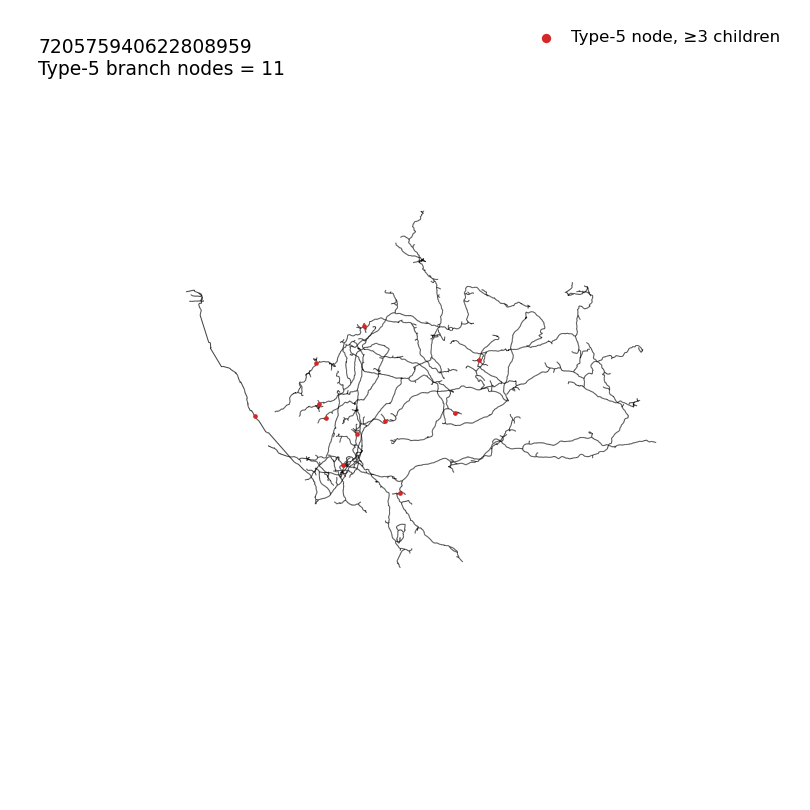

In [2]:
from pathlib import Path
from itertools import product, combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

nid = "720575940622808959"
swc_dir = Path("sk_lod1_783_healed_260609_fixed_classified/soma_need_check")
out = Path("pic")
out.mkdir(parents=True, exist_ok=True)

elev, azim = 22, -58
show_axes = False
show_branch_ids = False
branch_id_fontsize = 5
branch_id_offset = np.array([1.5, 1.5, 1.5])

d = np.atleast_2d(np.loadtxt(
    swc_dir / f"{nid}.swc",
    comments="#",
    usecols=(0, 1, 2, 3, 4, 6)
))

ids = d[:, 0].astype(np.int64)
types = d[:, 1].astype(np.int16)
xyz = d[:, 2:5] / 1000
parents = d[:, 5].astype(np.int64)
idx = {v: i for i, v in enumerate(ids)}

segments = np.array([
    [xyz[idx[p]], xyz[i]]
    for i, p in enumerate(parents)
    if p in idx
])

child_counts = pd.Series(parents[parents != -1]).value_counts()
branch_counts = np.array([
    child_counts.get(node_id, 0)
    for node_id in ids
])

branch_mask = (types == 5) & (branch_counts >= 3)
branch_xyz = xyz[branch_mask]
branch_ids = ids[branch_mask]

fig = plt.figure(figsize=(6.4, 5.5), dpi=150)
ax = fig.add_subplot(
    111,
    projection="3d",
    computed_zorder=False
)

if len(segments):
    ax.add_collection3d(Line3DCollection(
        segments,
        colors="black",
        linewidths=.5,
        alpha=.72,
        zorder=2
    ))

h = ax.scatter(
    *branch_xyz.T,
    s=5,
    color="#D62728",
    edgecolor=None,
    linewidth=0,
    depthshade=False,
    zorder=10
) if len(branch_xyz) else None

if show_branch_ids:
    for node_id, coord in zip(branch_ids, branch_xyz):
        label_xyz = coord + branch_id_offset
        ax.text(
            *label_xyz,
            str(node_id),
            fontsize=branch_id_fontsize,
            color="#D62728",
            ha="left",
            va="bottom",
            zorder=11
        )

ax.text2D(
    .03,
    .97,
    f"{nid}\nType-5 branch nodes = {len(branch_xyz)}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9
)

center = (xyz.min(0) + xyz.max(0)) / 2
radius = max(np.ptp(xyz, axis=0).max() / 2, 1e-6)

for setter, c in zip(
    [ax.set_xlim, ax.set_ylim, ax.set_zlim],
    center
):
    setter(c - radius, c + radius)

ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=elev, azim=azim)

if show_axes:
    ax.set_xlabel("X (μm)", fontsize=8, labelpad=1)
    ax.set_ylabel("Y (μm)", fontsize=8, labelpad=1)
    ax.set_zlabel("Z (μm)", fontsize=8, labelpad=1)
    ax.tick_params(labelsize=8, width=.8, length=3, pad=1)
    ax.grid(True)

    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((0.94, 0.97, 0.99, 0.28))
        axis.pane.set_edgecolor((0.72, 0.78, 0.84, 0.45))
        axis.line.set_color((1, 1, 1, 0))
        axis._axinfo["grid"].update({
            "color": (0.58, 0.68, 0.78, 0.42),
            "linewidth": .5,
            "linestyle": "-"
        })

    lims = [
        ax.get_xlim(),
        ax.get_ylim(),
        ax.get_zlim()
    ]

    corners = np.array(list(product(*lims)))
    box_center = np.array([np.mean(v) for v in lims])

    er, ar = np.deg2rad([elev, azim])

    camera = np.array([
        np.cos(er) * np.cos(ar),
        np.cos(er) * np.sin(ar),
        np.sin(er)
    ])

    top = corners[
        np.isclose(corners[:, 2], lims[2][1])
    ]

    hidden = top[
        np.argmax((top - box_center) @ camera)
    ]

    for p, q in combinations(corners, 2):
        if (
            np.sum(~np.isclose(p, q)) == 1
            and not np.allclose(p, hidden)
            and not np.allclose(q, hidden)
        ):
            ax.plot(
                *zip(p, q),
                color="#AEBBC8",
                lw=.8,
                zorder=0
            )
else:
    ax.set_axis_off()

if h is not None:
    ax.legend(
        [h],
        ["Type-5 node, ≥3 children"],
        loc="upper right",
        frameon=False,
        fontsize=8,
        markerscale=2,
        handletextpad=.5,
        labelspacing=.5
    )

fig.tight_layout()

suffix = "axes" if show_axes else "no_axes"

for ext, dpi in [("pdf", None), ("png", 600)]:
    fig.savefig(
        out / f"{nid}_type5_branch_nodes_3d_{suffix}.{ext}",
        dpi=dpi,
        bbox_inches="tight"
    )

plt.show()

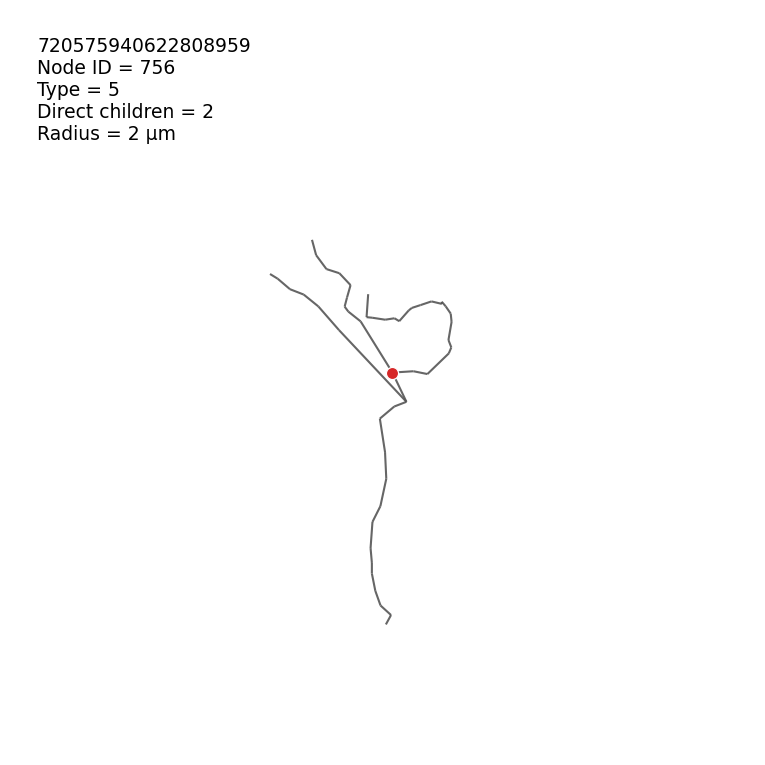

In [3]:
from pathlib import Path
from itertools import product, combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection


nid = "720575940622808959"
swc_dir = Path("sk_lod1_783_healed_260609_fixed_classified_binaryized/soma_need_check")
out = Path("pic")
out.mkdir(parents=True, exist_ok=True)

target_node_id = 756
zoom_radius = 2

elev, azim = 22, -58
show_axes = False
show_target_id = False
show_other_branch_nodes = True


d = np.atleast_2d(np.loadtxt(
    swc_dir / f"{nid}.swc",
    comments="#",
    usecols=(0, 1, 2, 3, 4, 6)
))

ids = d[:, 0].astype(np.int64)
types = d[:, 1].astype(np.int16)
xyz = d[:, 2:5] / 1000
parents = d[:, 5].astype(np.int64)

idx = {node_id: i for i, node_id in enumerate(ids)}

if target_node_id not in idx:
    raise ValueError(f"Node {target_node_id} does not exist")

target_i = idx[target_node_id]
target_xyz = xyz[target_i]
target_type = types[target_i]

segment_indices = [
    i for i, parent in enumerate(parents)
    if parent in idx
]

segments = np.array([
    [xyz[idx[parents[i]]], xyz[i]]
    for i in segment_indices
])

lower = target_xyz - zoom_radius
upper = target_xyz + zoom_radius

segment_min = segments.min(axis=1)
segment_max = segments.max(axis=1)

local_segment_mask = np.all(
    (segment_max >= lower) & (segment_min <= upper),
    axis=1
)

local_segments = segments[local_segment_mask]

local_node_mask = np.all(
    (xyz >= lower) & (xyz <= upper),
    axis=1
)

local_xyz = xyz[local_node_mask]
local_ids = ids[local_node_mask]
local_types = types[local_node_mask]

child_counts = pd.Series(
    parents[parents != -1]
).value_counts()

branch_counts = np.array([
    child_counts.get(node_id, 0)
    for node_id in ids
])

branch_mask = (
    (types == 5)
    & (branch_counts >= 3)
    & local_node_mask
)

branch_xyz = xyz[branch_mask]
branch_ids = ids[branch_mask]

fig = plt.figure(figsize=(5.6, 5.2), dpi=150)

ax = fig.add_subplot(
    111,
    projection="3d",
    computed_zorder=False
)

if len(local_segments):
    ax.add_collection3d(Line3DCollection(
        local_segments,
        colors="#555555",
        linewidths=1,
        alpha=.9,
        zorder=2
    ))

if show_other_branch_nodes and len(branch_xyz):
    other_mask = branch_ids != target_node_id

    if np.any(other_mask):
        ax.scatter(
            *branch_xyz[other_mask].T,
            s=8,
            color="#D62728",
            edgecolor="none",
            depthshade=False,
            zorder=8
        )

ax.scatter(
    *target_xyz,
    s=34,
    color="#D62728",
    edgecolor="white",
    linewidth=.6,
    depthshade=False,
    zorder=10
)

if show_target_id:
    offset = zoom_radius * .035

    ax.text(
        target_xyz[0] + offset,
        target_xyz[1] + offset,
        target_xyz[2] + offset,
        str(target_node_id),
        color="#D62728",
        fontsize=8,
        ha="left",
        va="bottom",
        zorder=11
    )

ax.text2D(
    .03,
    .97,
    (
        f"{nid}\n"
        f"Node ID = {target_node_id}\n"
        f"Type = {target_type}\n"
        f"Direct children = {branch_counts[target_i]}\n"
        f"Radius = {zoom_radius} μm"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9
)

ax.set_xlim(lower[0], upper[0])
ax.set_ylim(lower[1], upper[1])
ax.set_zlim(lower[2], upper[2])

ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=elev, azim=azim)

if show_axes:
    ax.set_xlabel("X (μm)", fontsize=8, labelpad=1)
    ax.set_ylabel("Y (μm)", fontsize=8, labelpad=1)
    ax.set_zlabel("Z (μm)", fontsize=8, labelpad=1)

    ax.tick_params(
        labelsize=8,
        width=.8,
        length=3,
        pad=1
    )

    ax.grid(True)

    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((0.94, 0.97, 0.99, 0.25))
        axis.pane.set_edgecolor((0.72, 0.78, 0.84, 0.4))
        axis.line.set_color((1, 1, 1, 0))

        axis._axinfo["grid"].update({
            "color": (0.58, 0.68, 0.78, 0.38),
            "linewidth": .45,
            "linestyle": "-"
        })

    lims = [
        ax.get_xlim(),
        ax.get_ylim(),
        ax.get_zlim()
    ]

    corners = np.array(list(product(*lims)))
    box_center = np.array([np.mean(v) for v in lims])

    er, ar = np.deg2rad([elev, azim])

    camera = np.array([
        np.cos(er) * np.cos(ar),
        np.cos(er) * np.sin(ar),
        np.sin(er)
    ])

    top = corners[
        np.isclose(corners[:, 2], lims[2][1])
    ]

    hidden = top[
        np.argmax((top - box_center) @ camera)
    ]

    for p, q in combinations(corners, 2):
        if (
            np.sum(~np.isclose(p, q)) == 1
            and not np.allclose(p, hidden)
            and not np.allclose(q, hidden)
        ):
            ax.plot(
                *zip(p, q),
                color="#AEBBC8",
                lw=.8,
                zorder=0
            )
else:
    ax.set_axis_off()

fig.tight_layout()

suffix = "axes" if show_axes else "no_axes"

for ext, dpi in [("pdf", None), ("png", 600)]:
    fig.savefig(
        out / (
            f"{nid}_node_{target_node_id}_"
            f"radius_{zoom_radius}_{suffix}.{ext}"
        ),
        dpi=dpi,
        bbox_inches="tight"
    )

plt.show()

## soma position

In [13]:
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

SWC_DIR = Path("sk_lod1_783_healed_260609")
META_PATH = "41586_2024_7686_MOESM5_ESM.tsv"

def has_type1_soma(path):
    with open(path, "r") as f:
        for line in f:
            if not line or line[0] == "#":
                continue
            p = line.split()
            if len(p) >= 7 and int(float(p[1])) == 1:
                return True
    return False

with_soma = set()
without_soma = set()

for f in tqdm(list(SWC_DIR.glob("*.swc")), desc="Scanning SWC soma type"):
    nid = f.stem
    if has_type1_soma(f):
        with_soma.add(nid)
    else:
        without_soma.add(nid)

df_meta = pd.read_csv(META_PATH, sep="\t")

df_meta_soma = df_meta[
    df_meta["root_id"].notna()
    & df_meta["nucleus_id"].notna()
    & df_meta["soma_x"].notna()
    & df_meta["soma_y"].notna()
    & df_meta["soma_z"].notna()
].copy()

df_meta_soma["root_id"] = (
    df_meta_soma["root_id"]
    .astype("int64")
    .astype(str)
)

meta_soma = set(df_meta_soma["root_id"])

print("SWC total:", len(with_soma | without_soma))
print("SWC with type=1 soma:", len(with_soma))
print("SWC without type=1 soma:", len(without_soma))
print("Meta soma:", len(meta_soma))

print("\nOverlap:")
print("with_soma ∩ meta_soma:", len(with_soma & meta_soma))
print("without_soma ∩ meta_soma:", len(without_soma & meta_soma))
print("meta_soma not in SWC:", len(meta_soma - (with_soma | without_soma)))

Scanning SWC soma type:   0%|          | 0/139273 [00:00<?, ?it/s]

SWC total: 139273
SWC with type=1 soma: 134689
SWC without type=1 soma: 4584
Meta soma: 107085

Overlap:
with_soma ∩ meta_soma: 107084
without_soma ∩ meta_soma: 1
meta_soma not in SWC: 0


/tmp/ipykernel_3987889/3684199348.py:31: DtypeWarning: Columns (14,15,16,17,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta = pd.read_csv(META_PATH, sep="\t")


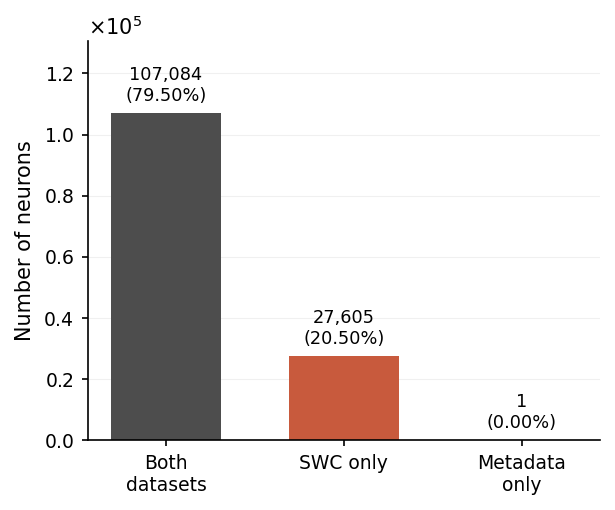

In [16]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

out = Path("pic")
out.mkdir(parents=True, exist_ok=True)

summary = pd.DataFrame({
    "Category": ["Both\ndatasets", "SWC only", "Metadata\nonly"],
    "Count": [
        len(with_soma & meta_soma),
        len(with_soma - meta_soma),
        len(without_soma & meta_soma)
    ]
})

total = summary["Count"].sum()
colors = ["#4D4D4D", "#C85A3D", "#B8B8B8"]

plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})
fig, ax = plt.subplots(figsize=(4.2, 3.5), dpi=150)

bars = ax.bar(
    summary["Category"], summary["Count"],
    width=.62, color=colors, edgecolor="none"
)

for bar, value in zip(bars, summary["Count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + summary["Count"].max() * .025,
        f"{value:,}\n({100 * value / total:.2f}%)",
        ha="center", va="bottom", fontsize=8.5
    )

ax.set_ylim(0, summary["Count"].max() * 1.22)
ax.set_ylabel("Number of neurons")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=9, width=.8, length=3)
ax.yaxis.grid(True, lw=.5, alpha=.18)
ax.set_axisbelow(True)

formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))
ax.yaxis.set_major_formatter(formatter)

fig.tight_layout()

for ext, dpi in [("pdf", None), ("png", 600)]:
    fig.savefig(
        out / f"soma_annotation_consistency.{ext}",
        dpi=dpi,
        bbox_inches="tight"
    )

plt.show()

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm

META_PATH = "41586_2024_7686_MOESM5_ESM.tsv"
SWC_DIR = Path("sk_lod1_783_healed_260609")
META_SCALE = np.array([250, 250, 25])
SWC_SCALE = 1000

meta = pd.read_csv(
    META_PATH,
    sep="\t",
    usecols=["root_id", "soma_x", "soma_y", "soma_z"]
).dropna()

meta["root_id"] = meta["root_id"].astype("int64").astype(str)
meta_dict = {
    r.root_id: np.array([r.soma_x, r.soma_y, r.soma_z]) / META_SCALE
    for r in meta.itertuples(index=False)
}

rows = []

for f in tqdm(list(SWC_DIR.glob("*.swc"))):
    nid = f.stem
    if nid not in meta_dict:
        continue

    try:
        d = np.loadtxt(f, comments="#", usecols=(1, 2, 3, 4))
        d = np.atleast_2d(d)
        soma = d[d[:, 0] == 1, 1:4]

        if soma.size:
            dist = np.linalg.norm(soma.mean(0) / SWC_SCALE - meta_dict[nid])
            rows.append((nid, dist))

    except Exception as e:
        print(f"Error: {f.name}: {e}")

df_dist = pd.DataFrame(rows, columns=["neuron", "distance_um"])
df_dist.to_csv("soma_distance_distribution.csv", index=False)

print(df_dist["distance_um"].describe(
    percentiles=[.5, .75, .9, .95, .99, .995, .999]
))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 139273/139273 [04:29<00:00, 516.32it/s]


count    118082.000000
mean          0.349000
std           2.561400
min           0.002741
50%           0.213760
75%           0.331018
90%           0.529616
95%           0.718824
99%           1.224436
99.5%         1.530066
99.9%        16.101693
max         213.572283
Name: distance_um, dtype: float64


/tmp/ipykernel_3987889/1532038110.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


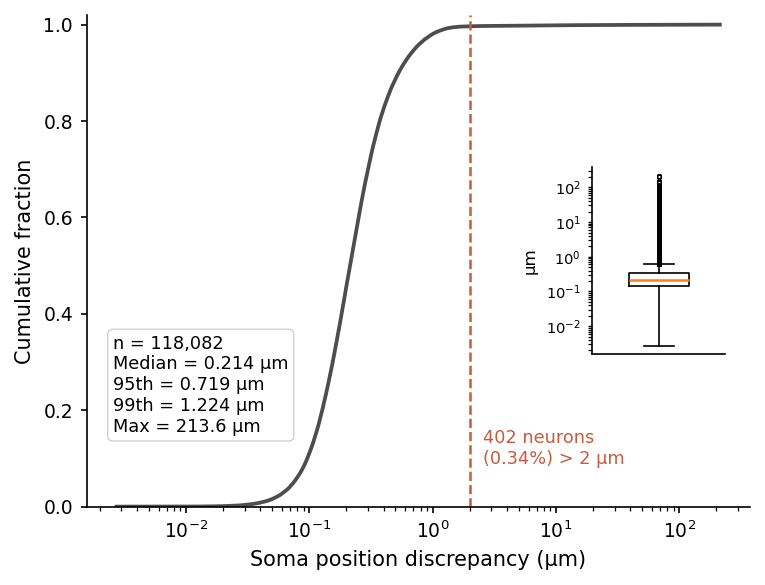

In [30]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

out = Path("pic")
out.mkdir(parents=True, exist_ok=True)

d = np.sort(df_dist["distance_um"].dropna().to_numpy())
cdf = np.arange(1, len(d) + 1) / len(d)

n = len(d)
n_gt2 = np.sum(d > 2)
stats = np.percentile(d, [50, 95, 99])

fig, ax = plt.subplots(figsize=(5.2, 4.0), dpi=150)

ax.plot(d, cdf, lw=1.8, color="#4D4D4D")
ax.axvline(2, ls="--", lw=1.2, color="#C85A3D")

ax.text(
    2.55, .08,
    f"{n_gt2:,} neurons\n({100 * n_gt2 / n:.2f}%) > 2 μm",
    color="#C85A3D", fontsize=8.5, ha="left", va="bottom"
)

ax.text(
    .04, .35,
    f"n = {n:,}\n"
    f"Median = {stats[0]:.3f} μm\n"
    f"95th = {stats[1]:.3f} μm\n"
    f"99th = {stats[2]:.3f} μm\n"
    f"Max = {d.max():.1f} μm",
    transform=ax.transAxes, fontsize=8.5, va="top",
    bbox=dict(boxstyle="round,pad=.3", fc="white", ec=".8", lw=.6)
)

ax.set(
    xscale="log",
    xlabel="Soma position discrepancy (μm)",
    ylabel="Cumulative fraction",
    ylim=(0, 1.02)
)

ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=9, width=.8, length=3)

ins = inset_axes(ax, width="20%", height="38%", loc="center right", borderpad=1.2)
ins.boxplot(
    d, widths=.45, showfliers=True,
    boxprops=dict(linewidth=.8),
    whiskerprops=dict(linewidth=.8),
    capprops=dict(linewidth=.8),
    medianprops=dict(linewidth=1.2),
    flierprops=dict(markersize=2, markeredgewidth=.4)
)
ins.set_yscale("log")
ins.set_xticks([])
ins.set_ylabel("μm", fontsize=8)
ins.tick_params(labelsize=7, width=.7, length=2)
ins.spines[["top", "right"]].set_visible(False)

fig.tight_layout()

for ext, dpi in [("pdf", None), ("png", 600)]:
    fig.savefig(
        out / f"soma_discrepancy_distribution.{ext}",
        dpi=dpi,
        bbox_inches="tight"
    )

plt.show()

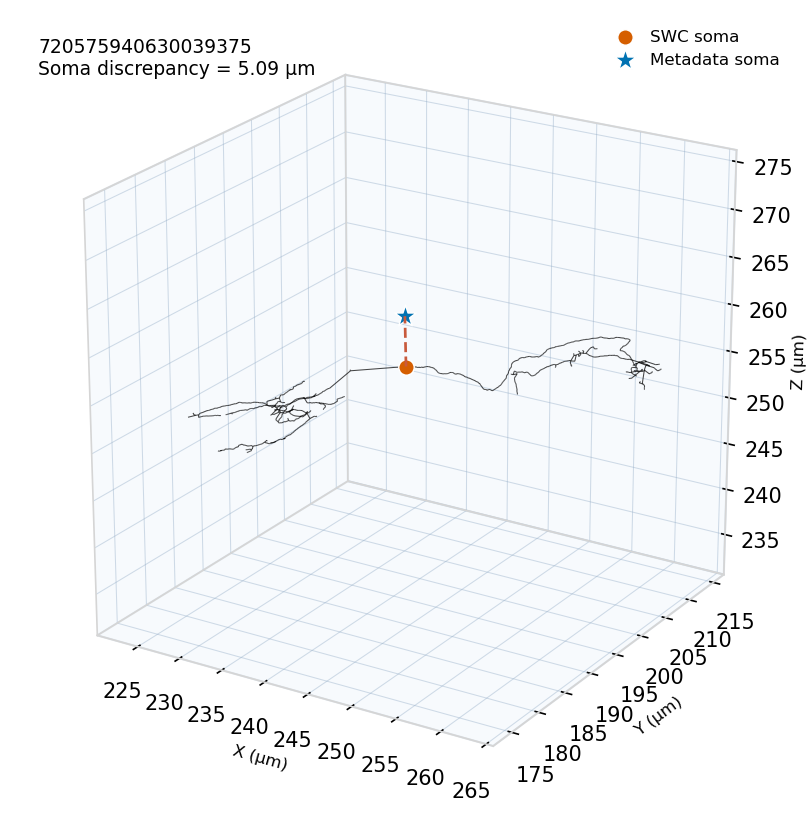

In [33]:
from pathlib import Path
from itertools import product, combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

nid = "720575940630039375"
swc_dir = Path("sk_lod1_783_healed_260609_fixed_classified/soma_need_check")
meta_path = "41586_2024_7686_MOESM5_ESM.tsv"
out = Path("pic")
out.mkdir(parents=True, exist_ok=True)

elev, azim = 22, -58

d = np.atleast_2d(np.loadtxt(
    swc_dir / f"{nid}.swc", comments="#",
    usecols=(0, 1, 2, 3, 4, 6)
))

ids = d[:, 0].astype(np.int64)
types = d[:, 1].astype(np.int16)
xyz = d[:, 2:5] / 1000
parents = d[:, 5].astype(np.int64)
idx = {v: i for i, v in enumerate(ids)}

segments = np.array([
    [xyz[idx[p]], xyz[i]]
    for i, p in enumerate(parents) if p in idx
])

swc_soma = xyz[types == 1]
swc_center = swc_soma.mean(0) if len(swc_soma) else None

meta = pd.read_csv(
    meta_path, sep="\t",
    usecols=["root_id", "soma_x", "soma_y", "soma_z"],
    dtype={"root_id": "string"}
).dropna()

meta["root_id"] = meta["root_id"].str.strip().str.replace(r"\.0$", "", regex=True)
row = meta.loc[meta["root_id"].eq(nid)]

meta_soma = (
    row[["soma_x", "soma_y", "soma_z"]].iloc[0].to_numpy(float)
    / np.array([250, 250, 25])
    if len(row) else None
)

fig = plt.figure(figsize=(6.4, 5.5), dpi=150)
ax = fig.add_subplot(111, projection="3d", computed_zorder=False)

if len(segments):
    ax.add_collection3d(Line3DCollection(
        segments, colors="black",
        linewidths=.5, alpha=.72, zorder=2
    ))

h1 = ax.scatter(
    *swc_soma.T, s=55, color="#D55E00",
    edgecolor="white", linewidth=.7,
    depthshade=False, zorder=10
) if len(swc_soma) else None

h2 = ax.scatter(
    *meta_soma, s=120, marker="*", color="#0072B2",
    edgecolor="white", linewidth=.7,
    depthshade=False, zorder=11
) if meta_soma is not None else None

if swc_center is not None and meta_soma is not None:
    dist = np.linalg.norm(swc_center - meta_soma)
    ax.plot(
        *zip(swc_center, meta_soma),
        color="#C85A3D", ls="--", lw=1.3, zorder=12
    )
    text = f"{nid}\nSoma discrepancy = {dist:.2f} μm"
else:
    text = nid

ax.text2D(
    .03, .97, text, transform=ax.transAxes,
    ha="left", va="top", fontsize=9
)

center = (xyz.min(0) + xyz.max(0)) / 2
radius = max(np.ptp(xyz, axis=0).max() / 2, 1e-6)

for setter, c in zip(
    [ax.set_xlim, ax.set_ylim, ax.set_zlim],
    center
):
    setter(c - radius, c + radius)

ax.set_box_aspect((1, 1, 1))
ax.set_xlabel("X (μm)", fontsize=8, labelpad=1)
ax.set_ylabel("Y (μm)", fontsize=8, labelpad=1)
ax.set_zlabel("Z (μm)", fontsize=8, labelpad=1)
    
ax.view_init(elev=elev, azim=azim)
ax.grid(True)

for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor((0.94, 0.97, 0.99, 0.28))
    axis.pane.set_edgecolor((0.72, 0.78, 0.84, 0.45))
    axis.line.set_color((1, 1, 1, 0))
    axis._axinfo["grid"].update({
        "color": (0.58, 0.68, 0.78, 0.42),
        "linewidth": 0.5,
        "linestyle": "-"
    })

lims = [ax.get_xlim(), ax.get_ylim(), ax.get_zlim()]
corners = np.array(list(product(*lims)))
box_center = np.array([np.mean(v) for v in lims])

er, ar = np.deg2rad([elev, azim])
camera = np.array([
    np.cos(er) * np.cos(ar),
    np.cos(er) * np.sin(ar),
    np.sin(er)
])

top = corners[np.isclose(corners[:, 2], lims[2][1])]
hidden = top[np.argmax((top - box_center) @ camera)]

for p, q in combinations(corners, 2):
    if (
        np.sum(~np.isclose(p, q)) == 1
        and not np.allclose(p, hidden)
        and not np.allclose(q, hidden)
    ):
        ax.plot(*zip(p, q), color="#D5D5D5", lw=.8, zorder=0)

handles = [h for h in (h1, h2) if h is not None]
labels = [
    label for h, label in zip(
        (h1, h2), ("SWC soma", "Metadata soma")
    ) if h is not None
]

if handles:
    ax.legend(
        handles, labels, loc="upper right",
        frameon=False, fontsize=8,
        handletextpad=.5, labelspacing=.5
    )

fig.tight_layout()

for ext, dpi in [("pdf", None), ("png", 600)]:
    fig.savefig(
        out / f"{nid}_soma_check_3d.{ext}",
        dpi=dpi, bbox_inches="tight"
    )

plt.show()

## type 0 

In [2]:
from pathlib import Path
from multiprocessing import Pool
from collections import Counter
import csv, json, os
import numpy as np
import pandas as pd
from tqdm import tqdm

CFG = {
    "swc_dir": "sk_lod1_783_healed_260609",
    "out_dir": "type0_branch_check",
    "processes": min(8, os.cpu_count() or 1),
    "chunksize": 1,
    "maxtasksperchild": 500,
    "resume": True
}

ROOT = None

SUMMARY_FIELDS = [
    "file", "relative_path", "n_nodes", "type0_n",
    "type0_terminal_n", "type0_continuation_n",
    "type0_bifurcation_n", "type0_multifurcation_n",
    "type0_branch_n", "type0_max_children",
    "has_type0_branch", "has_type0_multifurcation",
    "distribution", "error"
]

NODE_FIELDS = [
    "file", "relative_path", "node_id",
    "n_children", "is_branch", "is_multifurcation"
]


def init_worker(root):
    global ROOT
    ROOT = Path(root)


def check_one(path):
    path = Path(path)
    rel = str(path.relative_to(ROOT))

    try:
        d = np.loadtxt(path, comments="#", usecols=(0, 1, 6), ndmin=2)

        if not d.size:
            raise ValueError("Empty SWC")

        ids = d[:, 0].astype(np.int64)
        types = d[:, 1].astype(np.int16)
        parents = d[:, 2].astype(np.int64)

        if np.unique(ids).size != ids.size:
            raise ValueError("Duplicate node IDs")

        type0_ids = ids[types == 0]
        parent_ids, counts = np.unique(
            parents[parents != -1],
            return_counts=True
        )

        n_children = np.zeros(type0_ids.size, dtype=np.int32)

        if parent_ids.size and type0_ids.size:
            pos = np.searchsorted(parent_ids, type0_ids)
            valid = pos < parent_ids.size
            matched = np.zeros(type0_ids.size, dtype=bool)
            matched[valid] = parent_ids[pos[valid]] == type0_ids[valid]
            n_children[matched] = counts[pos[matched]]

        values, nums = np.unique(n_children, return_counts=True)
        dist = {int(k): int(v) for k, v in zip(values, nums)}
        branch = n_children >= 2

        summary = {
            "file": path.name,
            "relative_path": rel,
            "n_nodes": ids.size,
            "type0_n": type0_ids.size,
            "type0_terminal_n": np.sum(n_children == 0),
            "type0_continuation_n": np.sum(n_children == 1),
            "type0_bifurcation_n": np.sum(n_children == 2),
            "type0_multifurcation_n": np.sum(n_children >= 3),
            "type0_branch_n": np.sum(branch),
            "type0_max_children": n_children.max() if n_children.size else 0,
            "has_type0_branch": np.any(branch),
            "has_type0_multifurcation": np.any(n_children >= 3),
            "distribution": json.dumps(dist, separators=(",", ":")),
            "error": ""
        }

        nodes = [
            {
                "file": path.name,
                "relative_path": rel,
                "node_id": int(i),
                "n_children": int(n),
                "is_branch": True,
                "is_multifurcation": bool(n >= 3)
            }
            for i, n in zip(type0_ids[branch], n_children[branch])
        ]

        return summary, nodes

    except Exception as e:
        return {
            **{k: "" for k in SUMMARY_FIELDS},
            "file": path.name,
            "relative_path": rel,
            "distribution": "{}",
            "error": str(e)
        }, []


def processed_files(path):
    if not path.exists() or not CFG["resume"]:
        return set()

    try:
        return set(pd.read_csv(
            path,
            usecols=["relative_path"]
        )["relative_path"].dropna())
    except Exception:
        return set()


def aggregate(summary_path, distribution_path):
    df = pd.read_csv(summary_path, on_bad_lines="skip")
    df = df.drop_duplicates("relative_path", keep="last")
    df.to_csv(summary_path, index=False)

    ok = df[df["error"].isna() | df["error"].eq("")]
    dist = Counter()

    for s in ok["distribution"].dropna():
        try:
            dist.update({int(k): int(v) for k, v in json.loads(s).items()})
        except Exception:
            pass

    dd = pd.DataFrame(
        sorted(dist.items()),
        columns=["n_children", "n_type0_nodes"]
    )

    total = dd["n_type0_nodes"].sum() if len(dd) else 0
    dd["percentage"] = (
        dd["n_type0_nodes"] / total * 100
        if total else 0
    )
    dd.to_csv(distribution_path, index=False)

    cols = [
        "type0_n", "type0_branch_n",
        "type0_bifurcation_n", "type0_multifurcation_n"
    ]

    ok = ok.copy()
    ok[cols] = ok[cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    print("\n===== Summary =====")
    print("SWC files:", len(df))
    print("Errors:", len(df) - len(ok))
    print("Total Type-0 nodes:", int(ok["type0_n"].sum()))
    print("Type-0 nodes with >=2 children:", int(ok["type0_branch_n"].sum()))
    print("Type-0 nodes with exactly 2 children:", int(ok["type0_bifurcation_n"].sum()))
    print("Type-0 nodes with >=3 children:", int(ok["type0_multifurcation_n"].sum()))
    print("Files with branching Type-0 nodes:", int(ok["type0_branch_n"].gt(0).sum()))
    print("Files with multifurcating Type-0 nodes:", int(ok["type0_multifurcation_n"].gt(0).sum()))
    print("\n", dd.to_string(index=False))


def run():
    root = Path(CFG["swc_dir"])
    out = Path(CFG["out_dir"])
    out.mkdir(parents=True, exist_ok=True)

    summary_path = out / "type0_file_summary.csv"
    node_path = out / "type0_branch_node_details.csv"
    distribution_path = out / "type0_branch_distribution.csv"

    done = processed_files(summary_path)
    files = [
        p for p in sorted(root.rglob("*.swc"))
        if str(p.relative_to(root)) not in done
    ]

    print("Remaining:", len(files))

    summary_exists = summary_path.exists() and summary_path.stat().st_size
    node_exists = node_path.exists() and node_path.stat().st_size

    with summary_path.open("a", newline="", encoding="utf-8") as sf, \
         node_path.open("a", newline="", encoding="utf-8") as nf:

        sw = csv.DictWriter(sf, fieldnames=SUMMARY_FIELDS)
        nw = csv.DictWriter(nf, fieldnames=NODE_FIELDS)

        if not summary_exists:
            sw.writeheader()
        if not node_exists:
            nw.writeheader()

        with Pool(
            CFG["processes"],
            initializer=init_worker,
            initargs=(str(root),),
            maxtasksperchild=CFG["maxtasksperchild"]
        ) as pool:
            it = pool.imap_unordered(
                check_one,
                map(str, files),
                chunksize=CFG["chunksize"]
            )

            for n, (summary, nodes) in enumerate(
                tqdm(it, total=len(files), desc="Checking Type-0 nodes"),
                1
            ):
                sw.writerow(summary)

                if nodes:
                    nw.writerows(nodes)

                if n % 100 == 0:
                    sf.flush()
                    nf.flush()

    aggregate(summary_path, distribution_path)


if __name__ == "__main__":
    run()

Remaining: 139273


Checking Type-0 nodes: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 139273/139273 [00:43<00:00, 3206.94it/s]



===== Summary =====
SWC files: 139273
Errors: 0
Total Type-0 nodes: 649726857
Type-0 nodes with >=2 children: 2502
Type-0 nodes with exactly 2 children: 2441
Type-0 nodes with >=3 children: 61
Files with branching Type-0 nodes: 2502
Files with multifurcating Type-0 nodes: 61

  n_children  n_type0_nodes   percentage
          1      649724355 9.999961e+01
          2           2441 3.756963e-04
          3             60 9.234650e-06
          4              1 1.539108e-07


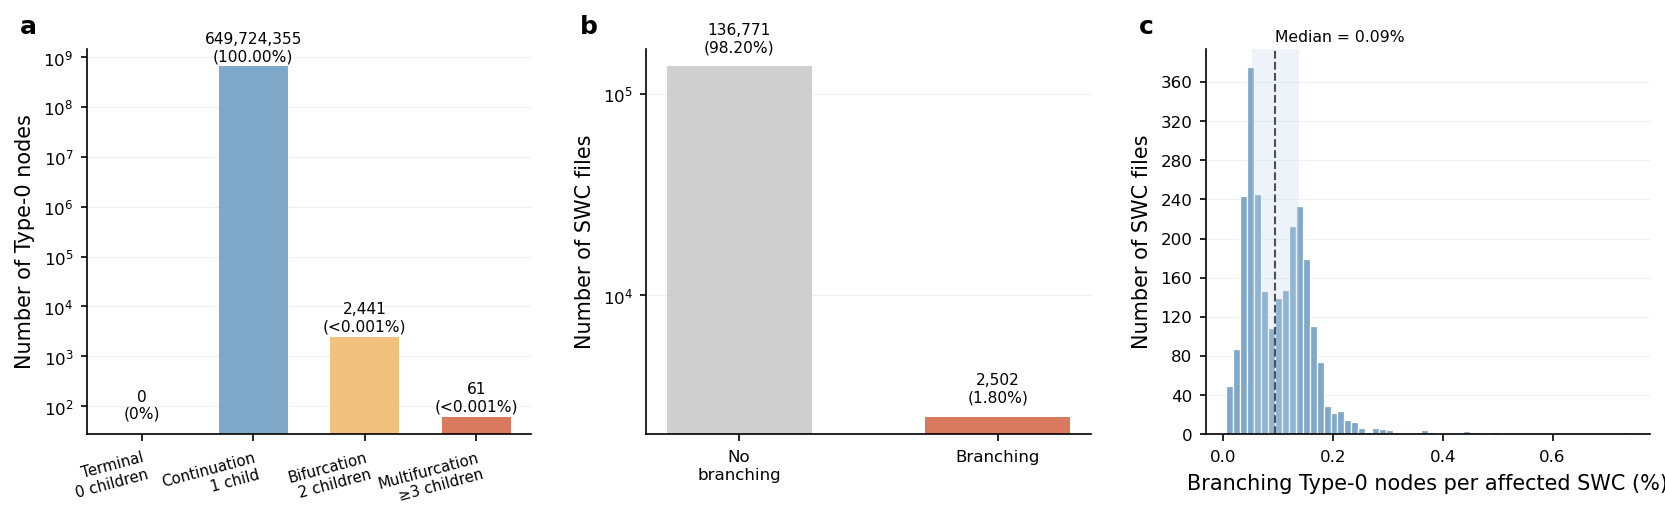

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, LogFormatterSciNotation, NullLocator, MaxNLocator

src, out = Path("type0_branch_check/type0_file_summary.csv"), Path("pic")
out.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(src)
ok = df[df["error"].isna() | df["error"].eq("")].copy()

cols = [
    "type0_n", "type0_terminal_n", "type0_continuation_n",
    "type0_bifurcation_n", "type0_multifurcation_n", "type0_branch_n"
]
ok[cols] = ok[cols].apply(pd.to_numeric, errors="coerce").fillna(0)

node_labels = [
    "Terminal\n0 children", "Continuation\n1 child",
    "Bifurcation\n2 children", "Multifurcation\n≥3 children"
]
node_values = [
    int(ok["type0_terminal_n"].sum()),
    int(ok["type0_continuation_n"].sum()),
    int(ok["type0_bifurcation_n"].sum()),
    int(ok["type0_multifurcation_n"].sum())
]

n_files = len(ok)
branch_files = int(ok["type0_branch_n"].gt(0).sum())
file_labels = ["No\nbranching", "Branching"]
file_values = [n_files - branch_files, branch_files]

affected = ok[(ok["type0_n"] > 0) & (ok["type0_branch_n"] > 0)].copy()
affected["branch_pct"] = affected["type0_branch_n"] / affected["type0_n"] * 100
x = affected["branch_pct"].replace([np.inf, -np.inf], np.nan).dropna().to_numpy()

def pct(v):
    if v == 0: return "0%"
    if v < .001: return "<0.001%"
    if v < .01: return f"{v:.3f}%"
    return f"{v:.2f}%"

def set_y(ax, values):
    pos = [v for v in values if v > 0]
    log = len(pos) > 1 and max(pos) / min(pos) >= 20
    if log:
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10))
        ax.yaxis.set_minor_locator(NullLocator())
    else:
        ax.set_ylim(0, max(values) * 1.25 if max(values) else 1)
        f = ScalarFormatter(useMathText=True)
        f.set_scientific(True)
        f.set_powerlimits((0, 0))
        ax.yaxis.set_major_formatter(f)
    return log

def annotate(ax, bars, values, total, log):
    m = max(values) if values else 0
    floor = min((v for v in values if v > 0), default=1) * .8
    for bar, v in zip(bars, values):
        y = max(v * 1.14, floor) if log else v + m * .025
        ax.text(
            bar.get_x() + bar.get_width() / 2, y,
            f"{v:,}\n({pct(100 * v / total if total else 0)})",
            ha="center", va="bottom", fontsize=7.4
        )

fig, ax = plt.subplots(1, 3, figsize=(11.2, 3.7), dpi=150)
fig.subplots_adjust(left=.07, right=.99, bottom=.25, top=.94, wspace=.43)

bars = ax[0].bar(
    node_labels, node_values, width=.62,
    color=["#BFD7EA", "#7FA8C9", "#F1C27D", "#D97A5E"],
    edgecolor="none"
)
log = set_y(ax[0], node_values)
annotate(ax[0], bars, node_values, sum(node_values), log)
ax[0].set_ylabel("Number of Type-0 nodes")
ax[0].tick_params(axis="x", labelsize=7.2, pad=4)
plt.setp(ax[0].get_xticklabels(), rotation=15, ha="right", rotation_mode="anchor")

bars = ax[1].bar(
    file_labels, file_values, width=.56,
    color=["#CFCFCF", "#D97A5E"], edgecolor="none"
)
log = set_y(ax[1], file_values)
annotate(ax[1], bars, file_values, n_files, log)
ax[1].set_ylabel("Number of SWC files")
ax[1].tick_params(axis="x", labelsize=8, pad=4)

if x.size:
    q1, med, q3 = np.percentile(x, [25, 50, 75])
    bins = np.histogram_bin_edges(x, bins="fd")
    if len(bins) < 6:
        bins = np.linspace(x.min(), x.max() if x.max() > x.min() else x.min() + 1, 8)

    ax[2].hist(x, bins=bins, color="#7FA8C9", edgecolor="white", linewidth=.6)
    ax[2].axvspan(q1, q3, color="#BFD7EA", alpha=.28, linewidth=0)
    ax[2].axvline(med, color="#4F4F4F", linestyle="--", linewidth=1)

    ax[2].text(
        med, 1.05, f"Median = {pct(med)}",
        transform=ax[2].get_xaxis_transform(),
        ha="left", va="top", fontsize=7.5
    )

ax[2].set_xlabel("Branching Type-0 nodes per affected SWC (%)")
ax[2].set_ylabel("Number of SWC files")
ax[2].yaxis.set_major_locator(MaxNLocator(integer=True))
ax[2].tick_params(axis="x", labelsize=8, pad=4)

for label, a in zip("abc", ax):
    a.text(-.15, 1.04, label, transform=a.transAxes, fontsize=12, fontweight="bold")
    a.spines[["top", "right"]].set_visible(False)
    a.spines[["left", "bottom"]].set_linewidth(.8)
    a.tick_params(axis="y", labelsize=8, width=.8, length=3)
    a.yaxis.grid(True, linewidth=.5, alpha=.18)
    a.set_axisbelow(True)

fig.tight_layout(rect=[0, .03, 1, 1], w_pad=2)

for ext, dpi in [("pdf", None), ("png", 600)]:
    fig.savefig(out / f"type0_branch_summary.{ext}", dpi=dpi, bbox_inches="tight")

plt.show()

In [71]:
from pathlib import Path
import pandas as pd

src=Path("type0_branch_check/type0_file_summary.csv")

df=pd.read_csv(src)
ok=df[df["error"].isna()|df["error"].eq("")].copy()

cols=[
    "type0_n","type0_terminal_n","type0_continuation_n",
    "type0_bifurcation_n","type0_multifurcation_n","type0_branch_n"
]
ok[cols]=ok[cols].apply(pd.to_numeric,errors="coerce").fillna(0).astype(int)

n_nodes=ok["type0_branch_n"].sum()
n_files=ok["type0_branch_n"].gt(0).sum()

print(f"Branching Type-0 nodes: {n_nodes:,}")
print(f"Affected SWC files:      {n_files:,}")

print("\ntype0_branch_n distribution:")
print(ok["type0_branch_n"].value_counts().sort_index())

print("\nMaximum per file:")
for c in ["type0_branch_n","type0_bifurcation_n","type0_multifurcation_n"]:
    print(f"{c}: {ok[c].max()}")

print("\nConsistency check:")
bad=ok[
    ok["type0_branch_n"] !=
    ok["type0_bifurcation_n"]+ok["type0_multifurcation_n"]
]
print(f"Inconsistent files: {len(bad):,}")

print("\nFiles containing >1 branching Type-0 node:")
multi=ok[ok["type0_branch_n"]>1]
print(f"n={len(multi):,}")
print(
    multi[
        ["file","type0_n","type0_bifurcation_n",
         "type0_multifurcation_n","type0_branch_n"]
    ].head(30).to_string(index=False)
)

if n_nodes==n_files and len(multi)==0:
    print("\nRESULT: Every affected file contains exactly ONE branching Type-0 node.")
elif len(multi)>0:
    print("\nRESULT: Some files contain multiple branching Type-0 nodes.")
else:
    print("\nRESULT: Check the summary-generation logic.")

Branching Type-0 nodes: 2,502
Affected SWC files:      2,502

type0_branch_n distribution:
type0_branch_n
0    136771
1      2502
Name: count, dtype: int64

Maximum per file:
type0_branch_n: 1
type0_bifurcation_n: 1
type0_multifurcation_n: 1

Consistency check:
Inconsistent files: 0

Files containing >1 branching Type-0 node:
n=0
Empty DataFrame
Columns: [file, type0_n, type0_bifurcation_n, type0_multifurcation_n, type0_branch_n]
Index: []

RESULT: Every affected file contains exactly ONE branching Type-0 node.


## type = 6

In [5]:
from pathlib import Path
from multiprocessing import Pool
import csv, os
import numpy as np
import pandas as pd
from tqdm import tqdm

CFG = {
    "swc_dir": "sk_lod1_783_healed_260609",
    "out_dir": "type6_terminal_check",
    "processes": min(8, os.cpu_count() or 1),
    "chunksize": 1,
    "maxtasksperchild": 500,
    "resume": True
}

ROOT = None

SUMMARY_FIELDS = [
    "file", "relative_path", "n_nodes", "type6_n",
    "type6_terminal_n", "type6_with_children_n",
    "type6_max_children", "all_type6_terminal", "error"
]

NODE_FIELDS = [
    "file", "relative_path", "node_id", "n_children"
]


def init_worker(root):
    global ROOT
    ROOT = Path(root)


def check_one(path):
    path = Path(path)
    rel = str(path.relative_to(ROOT))

    try:
        d = np.loadtxt(
            path,
            comments="#",
            usecols=(0, 1, 6),
            ndmin=2
        )

        if not d.size:
            raise ValueError("Empty SWC")

        ids = d[:, 0].astype(np.int64)
        types = d[:, 1].astype(np.int16)
        parents = d[:, 2].astype(np.int64)

        if np.unique(ids).size != ids.size:
            raise ValueError("Duplicate node IDs")

        type6_ids = ids[types == 6]

        parent_ids, counts = np.unique(
            parents[parents != -1],
            return_counts=True
        )

        n_children = np.zeros(type6_ids.size, dtype=np.int32)

        if parent_ids.size and type6_ids.size:
            pos = np.searchsorted(parent_ids, type6_ids)
            valid = pos < parent_ids.size
            matched = np.zeros(type6_ids.size, dtype=bool)
            matched[valid] = parent_ids[pos[valid]] == type6_ids[valid]
            n_children[matched] = counts[pos[matched]]

        abnormal = n_children > 0

        summary = {
            "file": path.name,
            "relative_path": rel,
            "n_nodes": int(ids.size),
            "type6_n": int(type6_ids.size),
            "type6_terminal_n": int(np.sum(n_children == 0)),
            "type6_with_children_n": int(np.sum(abnormal)),
            "type6_max_children": int(n_children.max()) if n_children.size else 0,
            "all_type6_terminal": bool(not np.any(abnormal)),
            "error": ""
        }

        nodes = [
            {
                "file": path.name,
                "relative_path": rel,
                "node_id": int(node_id),
                "n_children": int(count)
            }
            for node_id, count in zip(
                type6_ids[abnormal],
                n_children[abnormal]
            )
        ]

        return summary, nodes

    except Exception as e:
        return {
            **{k: "" for k in SUMMARY_FIELDS},
            "file": path.name,
            "relative_path": rel,
            "error": str(e)
        }, []


def processed_files(path):
    if not CFG["resume"] or not path.exists():
        return set()

    try:
        return set(
            pd.read_csv(
                path,
                usecols=["relative_path"]
            )["relative_path"].dropna()
        )
    except Exception:
        return set()


def run():
    root = Path(CFG["swc_dir"])
    out = Path(CFG["out_dir"])
    out.mkdir(parents=True, exist_ok=True)

    summary_path = out / "type6_file_summary.csv"
    node_path = out / "type6_nonterminal_nodes.csv"

    done = processed_files(summary_path)

    files = [
        p for p in sorted(root.rglob("*.swc"))
        if str(p.relative_to(root)) not in done
    ]

    print("Remaining:", len(files))

    summary_exists = summary_path.exists() and summary_path.stat().st_size > 0
    node_exists = node_path.exists() and node_path.stat().st_size > 0

    with summary_path.open("a", newline="", encoding="utf-8") as sf, \
         node_path.open("a", newline="", encoding="utf-8") as nf:

        sw = csv.DictWriter(sf, fieldnames=SUMMARY_FIELDS)
        nw = csv.DictWriter(nf, fieldnames=NODE_FIELDS)

        if not summary_exists:
            sw.writeheader()

        if not node_exists:
            nw.writeheader()

        with Pool(
            CFG["processes"],
            initializer=init_worker,
            initargs=(str(root),),
            maxtasksperchild=CFG["maxtasksperchild"]
        ) as pool:
            iterator = pool.imap_unordered(
                check_one,
                map(str, files),
                chunksize=CFG["chunksize"]
            )

            for i, (summary, nodes) in enumerate(
                tqdm(
                    iterator,
                    total=len(files),
                    desc="Checking Type-6 nodes"
                ),
                1
            ):
                sw.writerow(summary)

                if nodes:
                    nw.writerows(nodes)

                if i % 100 == 0:
                    sf.flush()
                    nf.flush()

    df = pd.read_csv(summary_path, on_bad_lines="skip")
    df = df.drop_duplicates("relative_path", keep="last")
    df.to_csv(summary_path, index=False)

    ok = df[df["error"].isna() | df["error"].eq("")].copy()

    cols = [
        "type6_n",
        "type6_terminal_n",
        "type6_with_children_n",
        "type6_max_children"
    ]

    ok[cols] = ok[cols].apply(
        pd.to_numeric,
        errors="coerce"
    ).fillna(0)

    print("\n===== Summary =====")
    print("SWC files:", len(df))
    print("Errors:", len(df) - len(ok))
    print("Total Type-6 nodes:", int(ok["type6_n"].sum()))
    print(
        "Terminal Type-6 nodes:",
        int(ok["type6_terminal_n"].sum())
    )
    print(
        "Type-6 nodes with children:",
        int(ok["type6_with_children_n"].sum())
    )
    print(
        "Files containing non-terminal Type-6 nodes:",
        int(ok["type6_with_children_n"].gt(0).sum())
    )
    print(
        "Maximum children of a Type-6 node:",
        int(ok["type6_max_children"].max()) if len(ok) else 0
    )


if __name__ == "__main__":
    run()

Remaining: 139273


Checking Type-6 nodes: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 139273/139273 [00:38<00:00, 3572.35it/s]



===== Summary =====
SWC files: 139273
Errors: 0
Total Type-6 nodes: 39910515
Terminal Type-6 nodes: 39910515
Type-6 nodes with children: 0
Files containing non-terminal Type-6 nodes: 0
Maximum children of a Type-6 node: 0


## segment length

In [36]:
from pathlib import Path
from multiprocessing import Pool
import csv
import os
import shutil
import numpy as np
import pandas as pd
from tqdm import tqdm

CFG = {
    "swc_dir": "sk_lod1_783_healed_260609_fixed_classified/unipolar",
    "out_dir": "multi_long_child_check",
    "coord_scale": [1000, 1000, 1000],
    "length_threshold_um": 5.0,
    "min_total_children": 2,
    "min_long_children": 2,
    "processes": min(24, os.cpu_count() or 1),
    "chunksize": 20,
    "maxtasksperchild": 2000,
    "clear_output": True
}

ROOT = None
SCALE = np.asarray(CFG["coord_scale"], dtype=float)

SUMMARY_FIELDS = [
    "file",
    "relative_path",
    "n_nodes",
    "n_valid_segments",
    "n_branch_parents",
    "n_matching_parents",
    "n_matching_long_segments",
    "max_long_children_same_parent",
    "has_matching_parent",
    "error"
]

DETAIL_FIELDS = [
    "file",
    "relative_path",
    "parent_id",
    "parent_type",
    "parent_children",
    "long_child_n",
    "long_child_ids",
    "long_child_types",
    "long_child_lengths_um",
    "min_long_child_length_um",
    "mean_long_child_length_um",
    "max_long_child_length_um",
    "parent_x_um",
    "parent_y_um",
    "parent_z_um"
]


def init_worker(root):
    global ROOT
    ROOT = Path(root)


def read_swc_fast(path):
    lines = []

    with open(path, "rb") as f:
        for line in f:
            stripped = line.lstrip()
            if stripped and not stripped.startswith(b"#"):
                lines.append(line)

    if not lines:
        raise ValueError("Empty SWC")

    try:
        data = np.fromstring(
            b"".join(lines).decode("ascii", errors="ignore"),
            sep=" "
        )

        n_rows = len(lines)

        if data.size % n_rows != 0:
            raise ValueError

        n_cols = data.size // n_rows

        if n_cols < 7:
            raise ValueError

        data = data.reshape(n_rows, n_cols)

        return data[:, [0, 1, 2, 3, 4, 6]]

    except Exception:
        return np.loadtxt(
            path,
            comments="#",
            usecols=(0, 1, 2, 3, 4, 6),
            ndmin=2
        )


def process_one(path):
    path = Path(path)
    relative_path = str(path.relative_to(ROOT))

    try:
        data = read_swc_fast(path)

        ids = data[:, 0].astype(np.int64)
        types = data[:, 1].astype(np.int16)
        xyz = data[:, 2:5].astype(float) / SCALE
        parents = data[:, 5].astype(np.int64)

        n_nodes = len(ids)

        if n_nodes == 0:
            raise ValueError("No valid nodes")

        order = np.argsort(ids)
        sorted_ids = ids[order]

        if np.any(sorted_ids[1:] == sorted_ids[:-1]):
            raise ValueError("Duplicate node IDs")

        nonroot = np.flatnonzero(parents != -1)
        parent_pos = np.searchsorted(
            sorted_ids,
            parents[nonroot]
        )

        matched = parent_pos < n_nodes
        valid_pos = np.flatnonzero(matched)

        matched[valid_pos] = (
            sorted_ids[parent_pos[valid_pos]]
            == parents[nonroot[valid_pos]]
        )

        node_idx = nonroot[matched]
        parent_idx = order[parent_pos[matched]]

        lengths = np.linalg.norm(
            xyz[node_idx] - xyz[parent_idx],
            axis=1
        )

        finite = np.isfinite(lengths)
        node_idx = node_idx[finite]
        parent_idx = parent_idx[finite]
        lengths = lengths[finite]

        child_count = np.bincount(
            parent_idx,
            minlength=n_nodes
        ).astype(np.int32)

        long_mask = (
            lengths > CFG["length_threshold_um"]
        )

        long_child_count = np.bincount(
            parent_idx[long_mask],
            minlength=n_nodes
        ).astype(np.int32)

        branch_parent_mask = (
            child_count >= CFG["min_total_children"]
        )

        matching_parent_mask = (
            branch_parent_mask
            & (
                long_child_count
                >= CFG["min_long_children"]
            )
        )

        matching_parents = np.flatnonzero(
            matching_parent_mask
        )

        details = []
        matching_long_segment_n = 0

        for parent in matching_parents:
            edge_mask = (
                (parent_idx == parent)
                & long_mask
            )

            children = node_idx[edge_mask]
            child_lengths = lengths[edge_mask]

            sort_order = np.argsort(
                child_lengths
            )[::-1]

            children = children[sort_order]
            child_lengths = child_lengths[sort_order]

            matching_long_segment_n += len(children)

            details.append({
                "file": path.name,
                "relative_path": relative_path,
                "parent_id": int(ids[parent]),
                "parent_type": int(types[parent]),
                "parent_children": int(
                    child_count[parent]
                ),
                "long_child_n": len(children),
                "long_child_ids": "|".join(
                    map(
                        str,
                        ids[children].astype(int)
                    )
                ),
                "long_child_types": "|".join(
                    map(
                        str,
                        types[children].astype(int)
                    )
                ),
                "long_child_lengths_um": "|".join(
                    f"{value:.6f}"
                    for value in child_lengths
                ),
                "min_long_child_length_um": float(
                    child_lengths.min()
                ),
                "mean_long_child_length_um": float(
                    child_lengths.mean()
                ),
                "max_long_child_length_um": float(
                    child_lengths.max()
                ),
                "parent_x_um": float(xyz[parent, 0]),
                "parent_y_um": float(xyz[parent, 1]),
                "parent_z_um": float(xyz[parent, 2])
            })

        summary = {
            "file": path.name,
            "relative_path": relative_path,
            "n_nodes": n_nodes,
            "n_valid_segments": len(lengths),
            "n_branch_parents": int(
                branch_parent_mask.sum()
            ),
            "n_matching_parents": len(
                matching_parents
            ),
            "n_matching_long_segments": (
                matching_long_segment_n
            ),
            "max_long_children_same_parent": (
                int(long_child_count.max())
                if len(long_child_count)
                else 0
            ),
            "has_matching_parent": bool(
                len(matching_parents)
            ),
            "error": ""
        }

        return summary, details

    except Exception as error:
        summary = {
            key: ""
            for key in SUMMARY_FIELDS
        }

        summary.update({
            "file": path.name,
            "relative_path": relative_path,
            "has_matching_parent": False,
            "error": str(error)
        })

        return summary, []


def run():
    root = Path(CFG["swc_dir"])
    out = Path(CFG["out_dir"])

    if CFG["clear_output"] and out.exists():
        shutil.rmtree(out)

    out.mkdir(parents=True, exist_ok=True)

    files = list(root.rglob("*.swc"))

    summary_path = out / "file_summary.csv"
    detail_path = out / "matching_parent_details.csv"
    matched_path = out / "matching_files.csv"
    filename_path = out / "matching_swc_filenames.csv"

    with (
        summary_path.open(
            "w",
            newline="",
            encoding="utf-8"
        ) as summary_file,
        detail_path.open(
            "w",
            newline="",
            encoding="utf-8"
        ) as detail_file
    ):
        summary_writer = csv.DictWriter(
            summary_file,
            fieldnames=SUMMARY_FIELDS
        )

        detail_writer = csv.DictWriter(
            detail_file,
            fieldnames=DETAIL_FIELDS
        )

        summary_writer.writeheader()
        detail_writer.writeheader()

        with Pool(
            processes=CFG["processes"],
            initializer=init_worker,
            initargs=(str(root),),
            maxtasksperchild=CFG["maxtasksperchild"]
        ) as pool:
            results = pool.imap_unordered(
                process_one,
                map(str, files),
                chunksize=CFG["chunksize"]
            )

            for i, (summary, details) in enumerate(
                tqdm(
                    results,
                    total=len(files),
                    desc="Checking long child segments"
                ),
                1
            ):
                summary_writer.writerow(summary)

                if details:
                    detail_writer.writerows(details)

                if i % 1000 == 0:
                    summary_file.flush()
                    detail_file.flush()

    summary = pd.read_csv(
        summary_path,
        low_memory=False
    )

    summary["n_matching_parents"] = pd.to_numeric(
        summary["n_matching_parents"],
        errors="coerce"
    ).fillna(0).astype(int)

    summary["n_matching_long_segments"] = pd.to_numeric(
        summary["n_matching_long_segments"],
        errors="coerce"
    ).fillna(0).astype(int)

    summary["max_long_children_same_parent"] = pd.to_numeric(
        summary["max_long_children_same_parent"],
        errors="coerce"
    ).fillna(0).astype(int)

    matched_files = summary[
        summary["n_matching_parents"] > 0
    ].copy()

    matched_files = matched_files.sort_values(
        [
            "n_matching_parents",
            "n_matching_long_segments",
            "max_long_children_same_parent"
        ],
        ascending=[False, False, False]
    )

    matched_files.to_csv(
        matched_path,
        index=False
    )

    matched_files[
        ["file"]
    ].to_csv(
        filename_path,
        index=False
    )

    if detail_path.exists():
        details = pd.read_csv(
            detail_path,
            low_memory=False
        )

        if len(details):
            details = details.sort_values(
                [
                    "long_child_n",
                    "max_long_child_length_um",
                    "mean_long_child_length_um"
                ],
                ascending=[False, False, False]
            )

        details.to_csv(
            detail_path,
            index=False
        )

    error_n = int(
        summary["error"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .sum()
    )

    print("\n===== Summary =====")
    print("SWC files:", len(summary))
    print(
        "Successfully processed:",
        len(summary) - error_n
    )
    print("Errors:", error_n)

    print(
        "Files with matching parent:",
        len(matched_files)
    )

    print(
        "Matching parent nodes:",
        int(
            matched_files[
                "n_matching_parents"
            ].sum()
        )
    )

    print(
        "Matching long child segments:",
        int(
            matched_files[
                "n_matching_long_segments"
            ].sum()
        )
    )

    print("\nMatching files:", matched_path)
    print("SWC filenames:", filename_path)
    print("Parent details:", detail_path)


if __name__ == "__main__":
    run()

Checking long child segments: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 117434/117434 [00:35<00:00, 3301.45it/s]



===== Summary =====
SWC files: 117434
Successfully processed: 117434
Errors: 0
Files with matching parent: 877
Matching parent nodes: 1344
Matching long child segments: 11827

Matching files: multi_long_child_check/matching_files.csv
SWC filenames: multi_long_child_check/matching_swc_filenames.csv
Parent details: multi_long_child_check/matching_parent_details.csv


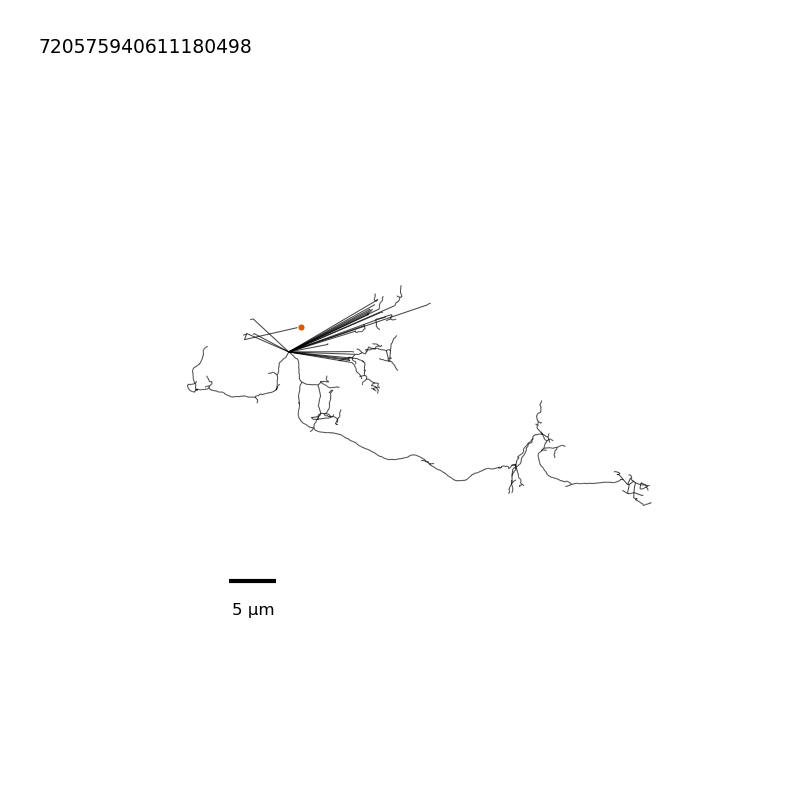

In [70]:
from pathlib import Path
from itertools import product, combinations
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

nid = "720575940611180498"
swc_dir = Path("sk_lod1_783_healed_260609_fixed_classified/unipolar")
out = Path("pic")
out.mkdir(parents=True, exist_ok=True)

view = "top"

views = {
    "default": (22, -58),
    "front": (0, -90),
    "side": (0, 0),
    "top": (90, -90),
    "back": (0, 90)
}

elev, azim = views[view]

show_axes = False
show_scale_bar = True
scale_bar_um = 5

show_soma = True
soma_color = "#D55E00"
soma_size = 12
soma_edgecolor = "white"
soma_linewidth = 0.5

d = np.atleast_2d(np.loadtxt(
    swc_dir / f"{nid}.swc",
    comments="#",
    usecols=(0, 1, 2, 3, 4, 6)
))

ids = d[:, 0].astype(np.int64)
types = d[:, 1].astype(np.int16)
xyz = d[:, 2:5] / 1000
parents = d[:, 5].astype(np.int64)
idx = {v: i for i, v in enumerate(ids)}

segments = np.array([
    [xyz[idx[p]], xyz[i]]
    for i, p in enumerate(parents)
    if p in idx
])

soma_xyz = xyz[types == 1]

fig = plt.figure(figsize=(6.4, 5.5), dpi=150)
ax = fig.add_subplot(
    111,
    projection="3d",
    computed_zorder=False
)

if len(segments):
    ax.add_collection3d(Line3DCollection(
        segments,
        colors="black",
        linewidths=.5,
        alpha=.72,
        zorder=2
    ))

if show_soma and len(soma_xyz):
    ax.scatter(
        soma_xyz[:, 0],
        soma_xyz[:, 1],
        soma_xyz[:, 2],
        s=soma_size,
        color=soma_color,
        edgecolor=soma_edgecolor,
        linewidth=soma_linewidth,
        depthshade=False,
        zorder=10
    )

ax.text2D(
    .03,
    .97,
    nid,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9
)

center = (xyz.min(0) + xyz.max(0)) / 2
radius = max(
    np.ptp(xyz, axis=0).max() / 2,
    1e-6
)

for setter, c in zip(
    [ax.set_xlim, ax.set_ylim, ax.set_zlim],
    center
):
    setter(c - radius, c + radius)

ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=elev, azim=azim)

if show_scale_bar:
    xr = ax.get_xlim()
    yr = ax.get_ylim()
    zr = ax.get_zlim()

    x0 = xr[0] + 0.08 * (xr[1] - xr[0])
    y0 = yr[0] + 0.08 * (yr[1] - yr[0])
    z0 = zr[0] + 0.08 * (zr[1] - zr[0])

    ax.plot(
        [x0, x0 + scale_bar_um],
        [y0, y0],
        [z0, z0],
        color="black",
        lw=2,
        solid_capstyle="butt",
        zorder=20
    )

    ax.text(
        x0 + scale_bar_um / 2,
        y0 - scale_bar_um / 2,
        z0 - scale_bar_um / 3,
        f"{scale_bar_um} μm",
        ha="center",
        va="top",
        fontsize=8,
        zorder=20
    )

if show_axes:
    ax.set_xlabel("X (μm)", fontsize=8, labelpad=1)
    ax.set_ylabel("Y (μm)", fontsize=8, labelpad=1)
    ax.set_zlabel("Z (μm)", fontsize=8, labelpad=1)

    ax.tick_params(
        labelsize=8,
        width=.8,
        length=3,
        pad=1
    )

    ax.grid(True)

    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((0.94, 0.97, 0.99, 0.28))
        axis.pane.set_edgecolor((0.72, 0.78, 0.84, 0.45))
        axis.line.set_color((1, 1, 1, 0))
        axis._axinfo["grid"].update({
            "color": (0.58, 0.68, 0.78, 0.42),
            "linewidth": .5,
            "linestyle": "-"
        })

    lims = [
        ax.get_xlim(),
        ax.get_ylim(),
        ax.get_zlim()
    ]

    corners = np.array(list(product(*lims)))
    box_center = np.array([
        np.mean(v)
        for v in lims
    ])

    er, ar = np.deg2rad([elev, azim])

    camera = np.array([
        np.cos(er) * np.cos(ar),
        np.cos(er) * np.sin(ar),
        np.sin(er)
    ])

    top = corners[
        np.isclose(
            corners[:, 2],
            lims[2][1]
        )
    ]

    hidden = top[
        np.argmax(
            (top - box_center) @ camera
        )
    ]

    for p, q in combinations(corners, 2):
        if (
            np.sum(~np.isclose(p, q)) == 1
            and not np.allclose(p, hidden)
            and not np.allclose(q, hidden)
        ):
            ax.plot(
                *zip(p, q),
                color="#AEBBC8",
                lw=.8,
                zorder=0
            )

else:
    ax.set_axis_off()

fig.tight_layout()

suffix = "axes" if show_axes else "no_axes"

for ext, dpi in [
    ("pdf", None),
    ("png", 600)
]:
    fig.savefig(
        out / f"{nid}_neuron_3d_{view}_{suffix}.{ext}",
        dpi=dpi,
        bbox_inches="tight"
    )

plt.show()